# Семинар 3. Свёртка и фильтрация: эксперимент и защита
**Курс: «Анализ изображений»**


## 0. Общие методы и импорты
Нужны `numpy`, `scipy`, `matplotlib`. Все изображения генерируются локально, скачивания не нужны.
`scikit-image` и `OpenCV` можно использовать дополнительно, если они установлены.

**Работаем с двумерными массивами `float32` в [0, 1]**. Для промежуточных производных и
повышения резкости диапазон может выходить за эти границы — сохраняйте эти значения.
Синтетические изображения нужны, чтобы знать эталон, размеры деталей и уровень шума.


NumPy: 2.1.3 SciPy: 1.16.3


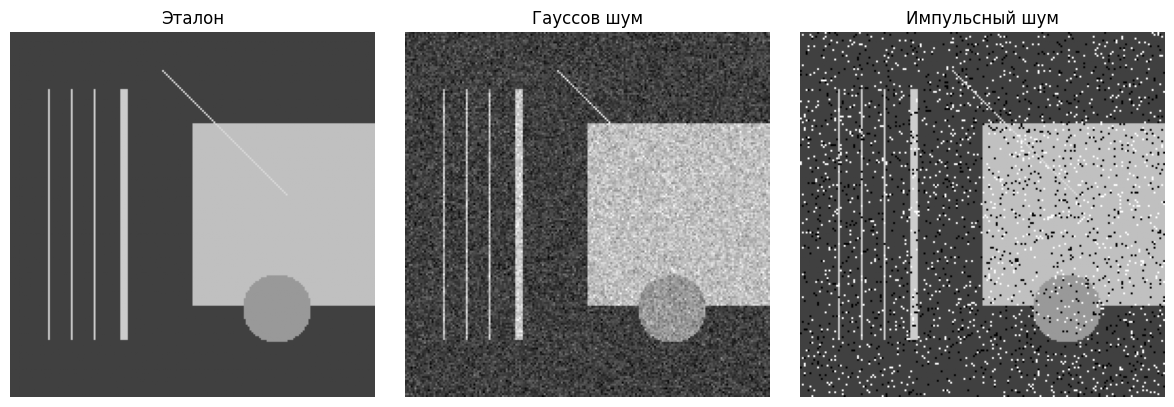

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import scipy

print("NumPy:", np.__version__, "SciPy:", scipy.__version__)
SEED = 17  # можно назначить каждому студенту своё значение; внутри опыта seed фиксируем


def show(images, titles=None, vmin=0, vmax=1):
    """Одна шкала для сопос/тавимых изображений; без скрытой автонормировки."""
    titles = titles or [""] * len(images)
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4), squeeze=False)
    for ax, image, title in zip(axes[0], images, titles):
        ax.imshow(image, cmap="gray", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def psnr(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    if reference.shape != estimate.shape:
        raise ValueError("PSNR: формы эталона и результата должны совпадать")
    error = np.mean((reference - estimate) ** 2)
    return float("inf") if error == 0 else float(10 * np.log10(1.0 / error))


def gaussian_noise(image, sigma=0.08, seed=SEED):
    rng = np.random.default_rng(seed)
    # clipping меняет распределение шума около 0 и 1 — учитывайте это в объяснении
    return np.clip(image + rng.normal(0, sigma, image.shape), 0, 1).astype(np.float32)


def impulse_noise(image, amount=0.08, seed=SEED):
    rng = np.random.default_rng(seed)
    mask = rng.random(image.shape)
    out = image.copy()
    out[mask < amount / 2] = 0
    out[mask > 1 - amount / 2] = 1
    return out


def make_scene(kind="details", n=192):
    image = np.full((n, n), 0.25, dtype=np.float32)
    if kind == "details":
        image[n//4:3*n//4, n//2:] = 0.75
        # тонкие вертикальные линии, толстая линия, диагональ
        for x in (20, 32, 44):
            image[30:n-30, x] = 0.80
        image[30:n-30, 58:62] = 0.80
        for t in range(20, n//2-10):
            image[t, t+60] = 0.85
        yy, xx = np.mgrid[:n, :n]
        image[(xx-140)**2 + (yy-145)**2 < 18**2] = 0.60
    elif kind == "smooth":
        yy, xx = np.mgrid[:n, :n]
        image = (0.25 + 0.25*xx/(n-1) +
                 0.25*np.exp(-((xx-n/2)**2+(yy-n/2)**2)/(2*(n/6)**2))).astype(np.float32)
    else:
        raise ValueError("kind: details или smooth")
    return image


clean = make_scene("details")
noisy_g = gaussian_noise(clean)
noisy_sp = impulse_noise(clean)
show([clean, noisy_g, noisy_sp], ["Эталон", "Гауссов шум", "Импульсный шум"])

## Карточка A. Почему похожие вызовы дают разные результаты?
**Вопрос:** как по эксперименту объяснить свёртку, корреляцию и влияние границ?
**Опора в лекции:** слайды 7–10 и 13–15. Базовая работа — опыты 1–3; опыт 4 дополнительный.

### До запуска
- Что будет на единичном импульсе для несимметричного ядра?
- Сохранит ли ядро постоянное изображение? Как вы это определили?
- Может ли разница двух результатов находиться только у рамки?

**Мой прогноз и причина:** …


In [ ]:
impulse = np.zeros((9, 9), dtype=np.float32)
impulse[4, 4] = 1
kernel_a = np.array([[0, 0, 0], [0, 1, 2], [0, 0, 1]], dtype=np.float32) / 4
numbers = np.arange(25, dtype=np.float32).reshape(5, 5)
print("Ядро:\n", kernel_a)
print("Матрица для ручного расчёта:\n", numbers)

# Здесь и далее пишите собственные ячейки или код в обозначенном месте.
# Подойдут ndimage.correlate, ndimage.convolve или ваш цикл.
# 1. Получите оба отклика на impulse и выведите массивы/тепловые карты.
# 2. Вручную вычислите оба результата для numbers в точке [2, 2].
# 3. Проверьте расчёт библиотекой. Зафиксируйте правила индексации и положение центра.


### Опыт 1. Объясните один пиксель
Покажите окно 3×3, соответствующие веса и каждое ненулевое слагаемое.
Объяснение «одна функция переворачивает ядро» дополните расчётом на выбранном окне.
Проверьте различие на ядре `kernel_a` и на симметричном box 3×3.

**Мой ручной расчёт:** …  
**Чем подтверждён вывод:** …

### Опыт 2. Разница в алгоритме или в границах?
Возьмите box 7×7 и изображение с неодинаковыми краями ниже. Сравните `constant` с `cval=0`,
`nearest`, `reflect`, `wrap` в **одной библиотеке**.
Покажите профиль верхней строки и максимальную разницу относительно `reflect`:
а) на всей картинке; б) после удаления рамки шириной 3 пикселя.
Проверьте отдельно постоянную картинку. Объясните один угловой пиксель для `constant`.

**Результат и граница применимости:** …


In [ ]:
border_image = np.full((31, 41), 0.6, dtype=np.float32)
border_image[:, -5:] = 0.9
border_image[-5:, :] = 0.2
constant_image = np.full_like(border_image, 0.6)
box7 = np.ones((7, 7), dtype=np.float32) / 49
border_results = {}  # заполните: название режима -> изображение

# Ваш код для опыта 2

if border_results:
    show(list(border_results.values()), list(border_results))


### Опыт 3. Можно ли восстановить фильтр по одному импульсу?
Сравните отклик box 3×3 и медианы 3×3 на одиночном импульсе.
Теперь проверьте медиану на маленьком квадрате ненулевых пикселей.
Почему один импульс не описывает поведение медианы на остальных изображениях?
Найдите два небольших массива X, Y, для которых в центре
`median_filter(X + Y) != median_filter(X) + median_filter(Y)`.

**Контрпример (массивы и три центральных числа):** …  
**Как он ограничивает вывод по импульсу:** …

### Опыт 4 — если осталось время
Разложите Собель на столбец и строку, сопоставьте 2D-операцию с двумя 1D-операциями.
Обеспечьте одинаковый режим границ и вид операции: свёртка либо корреляция.
Сравните `max(abs(full - separable))`. Почему экономия операций не гарантирует
точно такой же выигрыш по времени на небольшом массиве?

### Защита A
Научите слушателей вручную получать один пиксель. Покажите один контрпример.
Слушатель должен объяснить, почему на симметричном ядре легко пропустить различие операций.


## Карточка B. Как проверить рекомендацию «этот фильтр лучше»?
**Вопрос:** как выбрать фильтр для заданного шума и важных деталей?
**Опора в лекции:** слайды 18–25, 30–31, 38–41. Базовая работа — box, Гаусс, медиана.

### До запуска
Для каждого шума выберите предполагаемого победителя. Какие детали он может испортить?
Как изменится выбор, если главное — сохранить однопиксельные линии?

**Мой прогноз и причина:** …

### Опыт 1. Честное сравнение
Сравните «без фильтра», box (`size=3, 5`), Гаусс (`sigma=0.6, 1.2`),
медиану (`size=3, 5`) на **одних и тех же** `noisy_g` и `noisy_sp`.
Это семь вариантов для каждого шума. Границы везде `reflect`.
Сравнение показывает заданные конфигурации, а не доказывает превосходство семейства фильтров.
Гаусс: задайте `truncate=3.0`; размер его поддержки не равен автоматически размеру box.

Заполните словарь ниже. На один вариант приходится один результат для каждого шума.
Сохраняйте точные параметры в названии. PSNR требует чистого эталона.


In [ ]:
results_b = {"gaussian": {"без фильтра": noisy_g},
             "impulse": {"без фильтра": noisy_sp}}

# Ваш код: заполните results_b.
# Готовые функции допустимы: ndimage.uniform_filter, gaussian_filter, median_filter.
# Не генерируйте новую реализацию шума внутри цикла по фильтрам.


def report_b(results, reference):
    line_mask = np.zeros(reference.shape, dtype=bool)
    line_mask[40:150, 20] = True
    line_mask[40:150, 32] = True
    line_mask[40:150, 44] = True
    roi = (slice(20, 172), slice(12, 76))
    for noise_name, variants in results.items():
        print("\nШум:", noise_name)
        print(f'{"Вариант":28s} {"PSNR кадра":>11s} {"PSNR ROI":>10s} {"MAE линий":>10s}')
        for name, estimate in variants.items():
            if estimate.shape != reference.shape:
                raise ValueError("Сравнивайте все фильтры на одной области")
            line_error = np.mean(np.abs(estimate[line_mask]-reference[line_mask]))
            print(f'{name:28s} {psnr(reference, estimate):11.3f} '
                  f'{psnr(reference[roi], estimate[roi]):10.3f} {line_error:10.4f}')

report_b(results_b, clean)


### Опыт 2. Одно число и важная деталь
Для двух подходящих вариантов покажите одинаковый увеличенный фрагмент
`image[40:90, 12:76]`. Сопоставьте PSNR всего кадра, PSNR фиксированной ROI
и ошибку яркости на известных линиях. Последняя не измеряет все свойства восстановления.

Найдите компромисс: где меньше шума, а где лучше сохраняются линии?
Если метрики согласны, не выдумывайте конфликт: увеличьте окно до 7 либо уменьшите уровень шума,
зафиксируйте новое условие и повторите сравнение. Конфликт не гарантирован на каждом изображении.

**Моя рекомендация для фотографии:** …  
**Моя рекомендация для изображения тонких линий и её ограничения:** …

### Опыт 3. Перенос без повторной настройки
Выберите параметры по исходному seed и сохраните их в переменных.
Проверьте те же параметры на `SEED + 1` и на сцене `make_scene("smooth")`.
Сначала прогноз, затем новые результаты. Новый seed проверяет другую реализацию шума;
другая сцена проверяет зависимость от содержимого. Это учебная проверка, а не большой бенчмарк.

**Что сохранилось, что изменилось и почему:** …


In [ ]:
# Ваш код для опытов 2–3. При смене сцены создавайте шум заново и меняйте эталон.
# report_b применим только к исходной сцене details: маски линий в нём фиксированы.
# Для smooth достаточно общей PSNR и визуализации одной и той же области.


### Дополнение — если осталось время
Добавьте bilateral или NLM из `skimage.restoration`, если библиотека установлена.
Все методы, включая базовые, в этом сравнении запускайте на одном crop и считайте PSNR
относительно того же crop эталона. Запишите все параметры и режимы границ.
Почему изменение окна поиска NLM влияет на время?

### Защита B
Объясните на одном окне 3×3 разницу среднего и медианы; сами задайте его значения.
Покажите, чем результат подтверждает вашу рекомендацию и где она перестаёт работать.
Слушатель должен выбрать фильтр для нового типа шума и назвать возможную потерю деталей.


## Карточка C. Резче — значит лучше?
**Вопрос:** что именно усиливает unsharp masking и какие потери скрывает clip?
**Опора в лекции:** слайды 27–28; линейность — слайд 10.

### До запуска
Где появится изменение на ступеньке? Что будет на ровном участке с шумом?
Может ли «резкая» картинка иметь меньший PSNR к эталону?

**Мой прогноз и причина:** …

### Опыт 1. Разберите три слагаемых
Реализуйте функцию, возвращающую **три массива**: сглаженное изображение,
`details = image - blurred`, `raw = image + alpha * details`.
Не обрезайте raw внутри функции. Зафиксируйте `sigma=1.2`, `truncate=3.0`, `mode="reflect"`.
Сначала отдельно вычислите clipped-версию и сравните её с raw.

Для `alpha = 0, 0.5, 1.5, 3` получите профиль центральной строки ступеньки.
Покажите минимум и максимум raw, выход за [0,1] и выброс относительно уровней ступени 0.25/0.75.
Ореолы могут появиться ещё до выхода за [0,1]; доля clipped-пикселей не измеряет все ореолы.


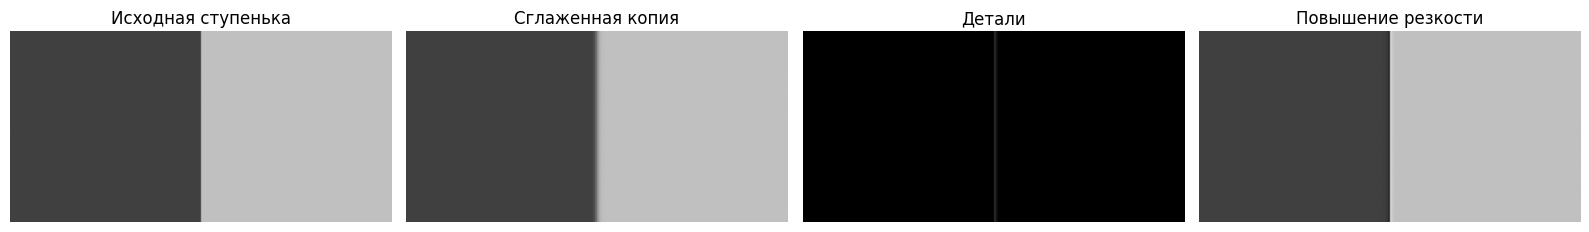

Исходный пиксель:    0.7500
После сглаживания:  0.5831
Разность:           0.1669
alpha:              0.5
Результат без clip: 0.8334


In [8]:
def investigate_unsharp(image, sigma=1.2, alpha=1.5):
    image = np.asarray(image, dtype=np.float32)

    blurred = ndimage.gaussian_filter(
        image,
        sigma=sigma,
        truncate=3.0,
        mode="reflect",
    )

    details = image - blurred
    raw = image + alpha * details

    # Промежуточный результат сохраняем без clip.
    return blurred, details, raw


step_c = np.full((96, 192), 0.25, dtype=np.float32)
step_c[:, 96:] = 0.75

step_noisy_c = gaussian_noise(
    step_c, sigma=0.04, seed=SEED
)

alpha_c = 0.5
blurred_c, details_c, raw_c = investigate_unsharp(
    step_c, sigma=1.2, alpha=alpha_c
)

show(
    [step_c, blurred_c, details_c, np.clip(raw_c, 0, 1)],
    ["Исходная ступенька", "Сглаженная копия", "Детали", "Повышение резкости"],
)

# Разберём один пиксель с яркой стороны границы.
y_c, x_c = 48, 96

print(f"Исходный пиксель:    {step_c[y_c, x_c]:.4f}")
print(f"После сглаживания:  {blurred_c[y_c, x_c]:.4f}")
print(f"Разность:           {details_c[y_c, x_c]:.4f}")
print(f"alpha:              {alpha_c}")
print(f"Результат без clip: {raw_c[y_c, x_c]:.4f}")

### Опыт 2. Что происходит с шумом?
Повторите опыт на `step_noisy_c`. Для каждой alpha измерьте PSNR к `step_c`
и стандартное отклонение **ошибки** `result - step_c` на ровном фрагменте `[15:80, 15:70]`.
Сравните исходный шум, raw и clipped. На фото покажите одинаковый crop, если фото доступно.
Не выбирайте «лучшее восстановление» только по ощущению резкости.

**Результаты и объяснение:** …

### Опыт 3. Проверка линейности
Выберите небольшие X, Y в [0,1] с перепадами яркости. Сравните:
- `F(X + Y)` и `F(X) + F(Y)` для unsharp **без clip**;
- то же для `F_clip(Z) = clip(F(Z), 0, 1)`.
Не обрезайте `X + Y` перед F: это добавит ещё одну нелинейную операцию.
Возможный вход за [0,1] здесь намеренный. Напечатайте максимальную разницу.
Если выбранный пример не проявил различие после clip, объясните почему и постройте другой.

**Мой контрпример и границы утверждения о линейности:** …


 alpha    min raw    max raw    ниже 0.25    выше 0.75   вне [0,1], %
   0.0     0.2500     0.7500       0.0000       0.0000           0.00
   0.5     0.1666     0.8334       0.0834       0.0834           0.00
   1.5    -0.0003     1.0003       0.2503       0.2503           1.04
   3.0    -0.2506     1.2506       0.5006       0.5006           1.04


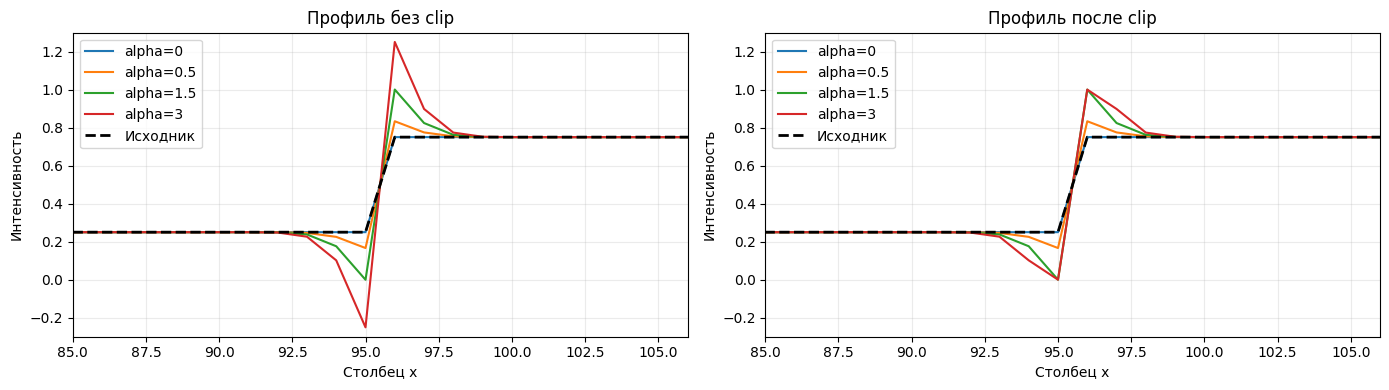

In [3]:
alphas_c = [0, 0.5, 1.5, 3]
results_c = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

print(
    f"{'alpha':>6} {'min raw':>10} {'max raw':>10} "
    f"{'ниже 0.25':>12} {'выше 0.75':>12} {'вне [0,1], %':>14}"
)

for alpha in alphas_c:
    _, _, raw = investigate_unsharp(step_c, alpha=alpha)
    clipped = np.clip(raw, 0, 1)
    results_c[alpha] = raw

    # Ореол оцениваем относительно уровней исходной ступеньки.
    undershoot = max(0.0, 0.25 - float(raw.min()))
    overshoot = max(0.0, float(raw.max()) - 0.75)
    outside = 100 * np.mean((raw < 0) | (raw > 1))

    print(
        f"{alpha:6.1f} {raw.min():10.4f} {raw.max():10.4f} "
        f"{undershoot:12.4f} {overshoot:12.4f} {outside:14.2f}"
    )

    axes[0].plot(raw[48], label=f"alpha={alpha}")
    axes[1].plot(clipped[48], label=f"alpha={alpha}")

for ax, title in zip(
    axes, ["Профиль без clip", "Профиль после clip"]
):
    ax.plot(
        step_c[48], color="black", linestyle="--",
        linewidth=2, label="Исходник"
    )
    ax.set_xlim(85, 106)
    ax.set_ylim(-0.3, 1.3)
    ax.set_title(title)
    ax.set_xlabel("Столбец x")
    ax.set_ylabel("Интенсивность")
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()
plt.close(fig)

 alpha     PSNR raw    PSNR clip   std ошибки raw   std ошибки clip
   0.0        27.92        27.92           0.0401            0.0401
   0.5        24.61        24.61           0.0581            0.0581
   1.5        20.17        20.30           0.0945            0.0944
   3.0        16.01        16.75           0.1493            0.1442


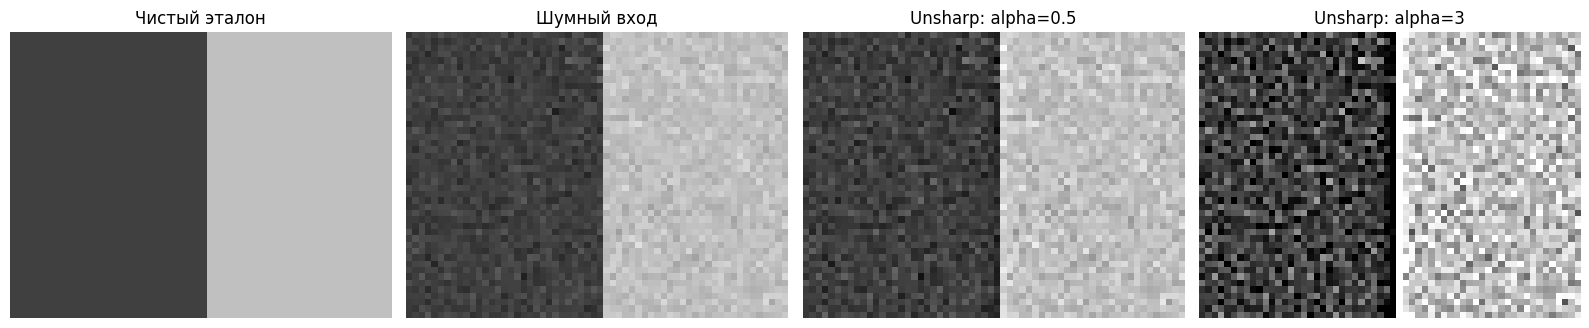

In [5]:
roi_c = (slice(15, 80), slice(15, 70))
noise_results_c = {}

print(
    f"{'alpha':>6} {'PSNR raw':>12} {'PSNR clip':>12} "
    f"{'std ошибки raw':>16} {'std ошибки clip':>17}"
)

for alpha in alphas_c:
    _, _, raw = investigate_unsharp(
        step_noisy_c, alpha=alpha
    )
    clipped = np.clip(raw, 0, 1)
    noise_results_c[alpha] = (raw, clipped)

    # Ошибка относительно эталона на ровной области,
    # вдали от границы ступеньки.
    error_raw = raw[roi_c] - step_c[roi_c]
    error_clip = clipped[roi_c] - step_c[roi_c]

    print(
        f"{alpha:6.1f} "
        f"{psnr(step_c, raw):12.2f} "
        f"{psnr(step_c, clipped):12.2f} "
        f"{np.std(error_raw):16.4f} "
        f"{np.std(error_clip):17.4f}"
    )

# Одинаковые область и шкала для визуального сравнения.
view_c = (slice(25, 70), slice(65, 125))

show(
    [
        step_c[view_c],
        step_noisy_c[view_c],
        noise_results_c[0.5][1][view_c],
        noise_results_c[3][1][view_c],
    ],
    [
        "Чистый эталон",
        "Шумный вход",
        "Unsharp: alpha=0.5",
        "Unsharp: alpha=3",
    ],
)

### Дополнение — если осталось время
Сравните эквивалентное ядро `delta + alpha*(delta - G)` с вашим unsharp.
Постройте дискретное G с тем же радиусом и нормировкой, что у библиотечного сглаживания.
Либо исследуйте порядок `median → unsharp` и `unsharp → median` на импульсном шуме:
зафиксируйте, на каких шагах используется clip. Не переносите свойства линейной свёртки на медиану.

### Защита C
На выбранном пикселе вычислите `image + alpha * (image - blurred)` по конкретным числам.
Покажите исходный профиль и raw: объясните, почему отрицательное кольцо ядра создаёт ореол.
Слушатель должен объяснить, почему усиление границы и восстановление эталона — разные цели.


## 4. Общая задача:

**Практическая цель:** подавить шум, сохранив тонкие линии для последующей сегментации.
1. Каждый предлагает цепочку максимум из двух операций и объясняет ожидаемый эффект.
2. До запуска укажите одну область, которая может пострадать.
3. Сравните исходный вход и предложения на одном эталоне и одной ROI.
4. Выберите рекомендацию под цель. Если все варианты плохи, объясните почему.
5. Сформулируйте, чего нельзя установить, когда чистого эталона в реальной задаче нет.

Это задача на перенос, а не соревнование по максимальному PSNR.


In [ ]:
transfer_clean = make_scene("details")
transfer_noisy = impulse_noise(
    gaussian_noise(transfer_clean, sigma=0.04, seed=SEED+10),
    amount=0.04, seed=SEED+11
)
show([transfer_clean, transfer_noisy], ["Эталон", "Новый вход: смешанный шум"])
# Ваши предложения и сравнение